In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import warnings

warnings.filterwarnings("ignore")

import os

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = (
    "expandable_segments:True"  # must precede `import torch`
)

!pip install pennylane pennylane-lightning --upgrade -q

import gc
import json
import pickle
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

sns.set_style("whitegrid")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 87.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 63.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 83.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 106.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 130.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 17.4 MB/s eta 0:00:00


In [ ]:
TRY_DUAL_GPU = False

N_GPUS = torch.cuda.device_count() if torch.cuda.is_available() else 0
DEVICE = torch.device("cuda:0") if N_GPUS >= 1 else torch.device("cpu")
DEVICE2 = torch.device("cuda:1") if (N_GPUS >= 2 and TRY_DUAL_GPU) else DEVICE
ALL_DEVICES = [DEVICE, DEVICE2] if DEVICE2 != DEVICE else [DEVICE]

print(
    f"CUDA available: {torch.cuda.is_available()}   GPU count: {N_GPUS}   dual-GPU mode: {DEVICE2 != DEVICE}"
)
for i in range(N_GPUS):
    print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")


def gpu_mem_report(tag=""):
    if not torch.cuda.is_available():
        return
    parts = []
    for i in range(N_GPUS):
        free, total = torch.cuda.mem_get_info(i)
        parts.append(f"GPU{i} {(total - free) / 1e9:.2f}/{total / 1e9:.2f} GB used")
    print(f"[mem{' ' + tag if tag else ''}] " + "  |  ".join(parts))


gpu_mem_report("initial")

CUDA available: True   GPU count: 1   dual-GPU mode: False
  GPU 0: Tesla T4
[mem initial] GPU0 0.11/15.64 GB used


In [ ]:
def is_oom_error(e):
    if hasattr(torch.cuda, "OutOfMemoryError") and isinstance(
        e, torch.cuda.OutOfMemoryError
    ):
        return True
    return "out of memory" in str(e).lower()


def is_fatal_cuda_error(e):
    msg = str(e).lower()
    return (
        "illegal memory access" in msg
        or "device-side assert" in msg
        or "misaligned address" in msg
    )


def safe_empty_cache():
    gc.collect()
    if torch.cuda.is_available():
        try:
            torch.cuda.empty_cache()
            torch.cuda.synchronize()
        except RuntimeError as e:
            if is_fatal_cuda_error(e):
                print(
                    "  [FATAL] CUDA context appears corrupted -- restart the kernel before further GPU cells."
                )
            else:
                raise


def run_batched_safely(
    fn, *args, batch_size=8, min_batch=1, on_fail=None, label="", **kwargs
):
    bs = batch_size
    while True:
        try:
            return fn(*args, batch_size=bs, **kwargs)
        except RuntimeError as e:
            if is_fatal_cuda_error(e):
                print(
                    f"  [FATAL{' ' + label if label else ''}] non-recoverable CUDA error, not retrying: {e}"
                )
                safe_empty_cache()
                return on_fail() if on_fail is not None else None
            elif is_oom_error(e) and bs > min_batch:
                print(
                    f"  [OOM{' ' + label if label else ''}] batch_size={bs} failed -> retrying at {max(bs // 2, min_batch)}"
                )
                safe_empty_cache()
                bs = max(bs // 2, min_batch)
                continue
            elif is_oom_error(e):
                print(
                    f"  [OOM{' ' + label if label else ''}] failed even at batch_size={min_batch}. Skipping."
                )
                safe_empty_cache()
                return on_fail() if on_fail is not None else None
            else:
                raise


print("Memory-safety helpers ready.")

Memory-safety helpers ready.


In [ ]:
NOTEBOOK_NAME = "BOT_training"
print(f"The notebook name is: {NOTEBOOK_NAME}")


SCRIPTS_PATH = "/content/drive/MyDrive/kaggle_datasets/QSNET_DATASETS"

if SCRIPTS_PATH not in sys.path:
    sys.path.append(SCRIPTS_PATH)

import scripts

print(scripts.__file__)

The notebook name is: BOT_training
/content/drive/MyDrive/kaggle_datasets/QSNET_DATASETS/scripts/__init__.py


In [ ]:
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler

from scripts.cache import (
    ForwardCache,
    cached_predict_labels,
)
from scripts.circuit import build_forward_circuit, create_quantum_device
from scripts.constants import (
    BARREN_PLATEAU_VAR_THRESHOLD,
    DEFAULT_ALPHA,
    DEFAULT_LAMBDA1,
    DEFAULT_LAMBDA2,
    DEFAULT_NOISE_RATE,
    DEFAULT_PATIENCE,
    INPUT_DIM_D,
)
from scripts.data import (
    capped_sample,
    class_balance_table,
    plot_class_balance_bars,
    plot_class_balance_pie,
    stratified_head,
)
from scripts.gradient import gradient_variance_probe
from scripts.theory import (
    verify_fidelity_convention,
)
from scripts.train import train_maqt

print("scripts package imported successfully ")

scripts package imported successfully 


In [ ]:
check = verify_fidelity_convention(dim=4, n_trials=30, seed=SEED)
print("Fidelity-convention self-check PASSED:", check)

AssertionError: fidelity mismatch: 7.476e-06 (please ensure non-squared fidelity is used!)

In [ ]:
DATA_PATH = "/content/drive/MyDrive/kaggle_datasets/QSNET_DATASETS/BoT-IoT"

df_train = pd.read_parquet(f"{DATA_PATH}/q8_train.parquet")
df_test = pd.read_parquet(f"{DATA_PATH}/q8_test.parquet")
df_cal = pd.read_parquet(f"{DATA_PATH}/q8_calibration.parquet")
df_zeroday = pd.read_parquet(f"{DATA_PATH}/q8_zeroday.parquet")

for name, df in [
    ("train", df_train),
    ("test", df_test),
    ("cal", df_cal),
    ("zeroday", df_zeroday),
]:
    print(f"{name:8s}: {df.shape}")
df_train.head()

train   : (130205, 11)
test    : (18601, 11)
cal     : (18601, 11)
zeroday : (683, 11)


,rate,state,bytes,srate,dpkts,pkts,dbytes,dur,label_multiclass,label_binary,label_family
0,0.030780,1.570796,0.330389,0.032406,0.0,0.294594,0.0,1.289262,DoS,1,dos
1,0.040153,1.570796,0.427413,0.042274,0.0,0.403320,0.0,1.390858,DoS,1,dos
2,0.114465,1.570796,0.473513,0.120511,0.0,0.457130,0.0,1.034863,DDoS,1,ddos
3,0.051103,2.356194,0.525070,0.053802,0.0,0.294594,0.0,1.086445,DDoS,1,ddos
4,0.018999,2.356194,0.419518,0.020003,0.0,0.185868,0.0,1.221108,DoS,1,dos


In [ ]:
df_train.label_multiclass.value_counts()

,count
label_multiclass,
DDoS,65913
DoS,56977
Normal,4836
Reconnaissance,2479


In [ ]:
df_cal.label_multiclass.value_counts()

,count
label_multiclass,
DDoS,9416
DoS,8140
Normal,691
Reconnaissance,354


In [ ]:
for df in [df_train, df_test, df_cal, df_zeroday]:
    df.drop(columns=["label_family", "label_binary"], inplace=True, errors="ignore")


def clean_features(df, feature_cols):
    df = df.copy()
    df[feature_cols] = df[feature_cols].replace([np.inf, -np.inf], np.nan)
    n_before = len(df)
    df = df[df[feature_cols].isna().mean(axis=1) < 0.5]
    df[feature_cols] = df[feature_cols].fillna(
        df[feature_cols].median(numeric_only=True)
    )
    df[feature_cols] = df[feature_cols].fillna(0.0)
    if len(df) < n_before:
        print(f"  dropped {n_before - len(df)} rows with excessive missing values")
    return df.reset_index(drop=True)


_feature_cols_raw = [c for c in df_train.columns if c != "label_multiclass"]
print(f"Raw numeric feature columns ({len(_feature_cols_raw)}): {_feature_cols_raw}")

df_train = clean_features(df_train, _feature_cols_raw)
df_test = clean_features(df_test, _feature_cols_raw)
df_cal = clean_features(df_cal, _feature_cols_raw)
df_zeroday = clean_features(df_zeroday, _feature_cols_raw)

MAX_CLASSES = 6
top_classes = df_train.label_multiclass.value_counts().head(MAX_CLASSES).index.tolist()
print(f"\nUsing top {len(top_classes)} classes: {top_classes}")

df_train_f = df_train[df_train.label_multiclass.isin(top_classes)].reset_index(
    drop=True
)
df_test_f = df_test[df_test.label_multiclass.isin(top_classes)].reset_index(drop=True)
df_cal_f = df_cal[df_cal.label_multiclass.isin(top_classes)].reset_index(drop=True)
df_zeroday_f = df_zeroday.reset_index(drop=True)

le = LabelEncoder()
le.fit(top_classes)
CLASS_NAMES = list(le.classes_)
N_CLASSES = len(CLASS_NAMES)
print(f"Encoded classes ({N_CLASSES}): {dict(enumerate(CLASS_NAMES))}")

feature_columns = [c for c in df_train.columns if c != "label_multiclass"]
target_column = "label_multiclass"

Raw numeric feature columns (8): ['rate', 'state', 'bytes', 'srate', 'dpkts', 'pkts', 'dbytes', 'dur']

Using top 4 classes: ['DDoS', 'DoS', 'Normal', 'Reconnaissance']
Encoded classes (4): {0: np.str_('DDoS'), 1: np.str_('DoS'), 2: np.str_('Normal'), 3: np.str_('Reconnaissance')}


In [ ]:
PER_CLASS_CAP = 3
CAL_TEST_CAP = 5
ZERODAY_CAP = 10

X_train_raw = df_train_f[feature_columns].values
y_train_raw = le.transform(df_train_f[target_column])
X_train, y_train = capped_sample(
    X_train_raw, y_train_raw, per_class_cap=PER_CLASS_CAP, seed=SEED
)

X_test_raw = df_test_f[feature_columns].values
y_test_raw = le.transform(df_test_f[target_column])
X_test, y_test = stratified_head(X_test_raw, y_test_raw, n=CAL_TEST_CAP, seed=SEED)

X_cal_raw = df_cal_f[feature_columns].values
y_cal_raw = le.transform(df_cal_f[target_column])
X_cal, y_cal = stratified_head(X_cal_raw, y_cal_raw, n=CAL_TEST_CAP, seed=SEED)

X_zeroday = df_zeroday_f[feature_columns].values[:ZERODAY_CAP]

print(
    f"X_train: {X_train.shape}  X_test: {X_test.shape}  X_cal: {X_cal.shape}  X_zeroday: {X_zeroday.shape}"
)
class_balance_table(y_train, CLASS_NAMES)

X_train: (12, 8)  X_test: (5, 8)  X_cal: (5, 8)  X_zeroday: (10, 8)


,class,count,pct
0,DDoS,3,25.0
1,DoS,3,25.0
2,Normal,3,25.0
3,Reconnaissance,3,25.0


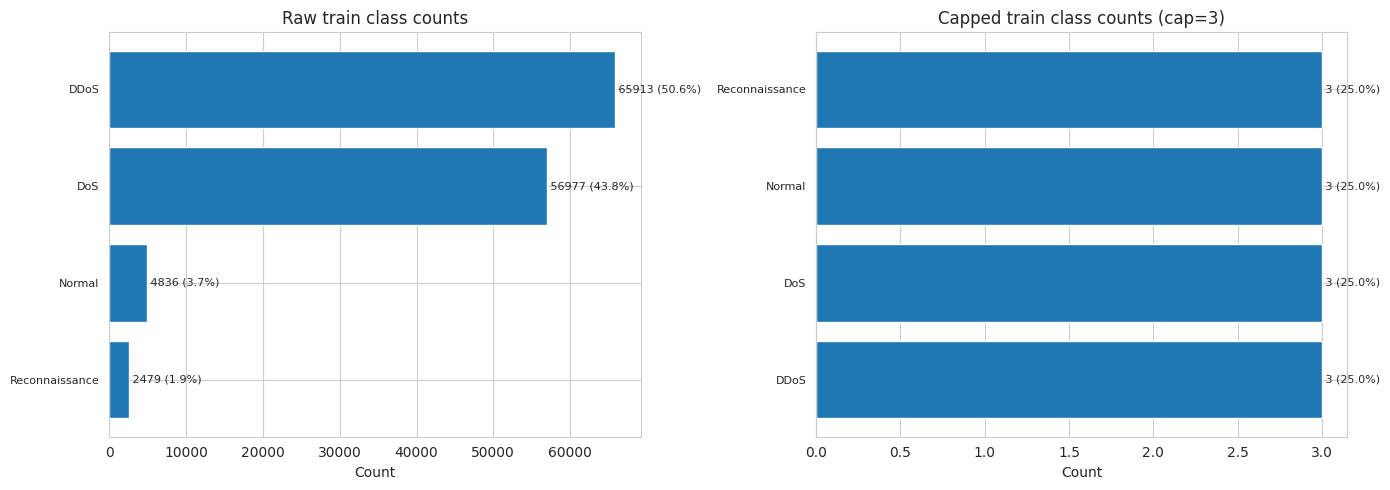

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
plot_class_balance_bars(
    y_train_raw, CLASS_NAMES, title="Raw train class counts", ax=ax[0]
)
plot_class_balance_bars(
    y_train,
    CLASS_NAMES,
    title=f"Capped train class counts (cap={PER_CLASS_CAP})",
    ax=ax[1],
)
plt.tight_layout()
plt.show()

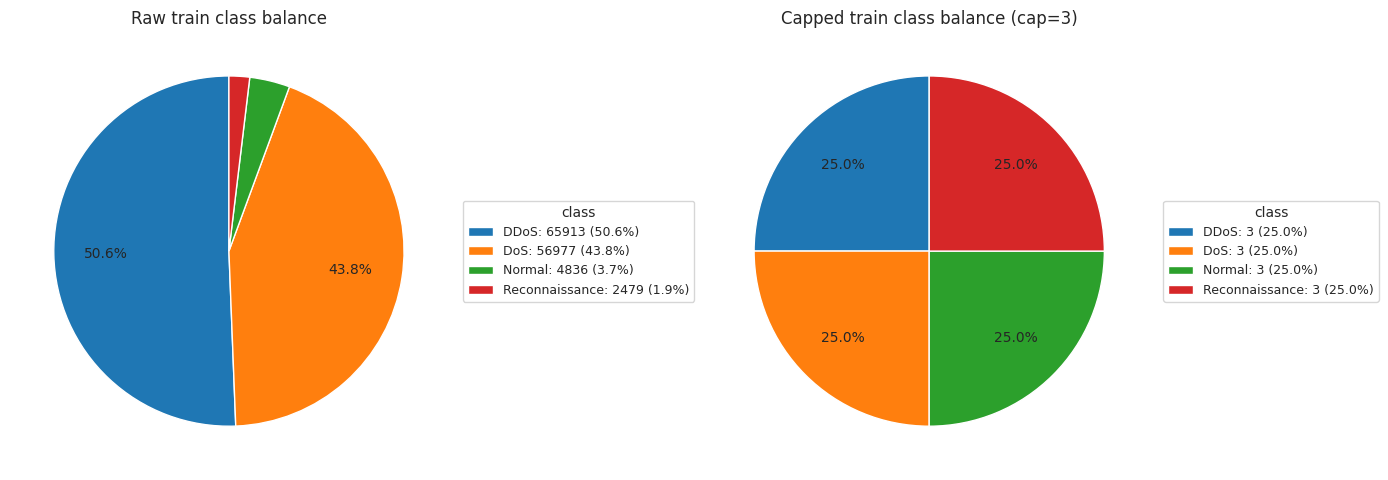

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 7))
plot_class_balance_pie(
    y_train_raw, CLASS_NAMES, title="Raw train class balance", ax=ax[0]
)
plot_class_balance_pie(
    y_train,
    CLASS_NAMES,
    title=f"Capped train class balance (cap={PER_CLASS_CAP})",
    ax=ax[1],
)
plt.tight_layout()
plt.show()

In [ ]:
USE_PCA = True  # <-- flip to False to skip PCA and angle-encode standardized raw features directly
TARGET_VARIANCE = 0.95

In [ ]:
MANUAL_N_QUBITS = None


N_QUBITS = INPUT_DIM_D
N_LAYERS = 3
REUPLOAD = True
NOISE_P = DEFAULT_NOISE_RATE

TRAIN_BATCH_SIZE = 8
QBATCH = 8
CACHE_BATCH = 256
n_raw_features = len(feature_columns)
print(f"Raw numeric feature columns available: {n_raw_features}")
if n_raw_features != N_QUBITS:
    print(
        f"NOTE: raw feature count ({n_raw_features}) != N_QUBITS ({N_QUBITS}). Either adjust "
        f"N_QUBITS or select exactly {N_QUBITS} columns before angle-encoding."
    )

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_cal_scaled = scaler.transform(X_cal)
X_zeroday_scaled = scaler.transform(X_zeroday)

if USE_PCA:
    pca_full = PCA(
        n_components=min(n_raw_features, X_train_scaled.shape[1]), random_state=SEED
    )
    pca_full.fit(X_train_scaled)
    cum_var = np.cumsum(pca_full.explained_variance_ratio_)

    if MANUAL_N_QUBITS is not None:
        N_QUBITS = MANUAL_N_QUBITS
        if N_QUBITS > n_raw_features:
            raise ValueError(
                f"MANUAL_N_QUBITS ({N_QUBITS}) cannot exceed raw features ({n_raw_features})."
            )
    else:
        N_QUBITS = int(np.argmax(cum_var >= TARGET_VARIANCE) + 1)
        print(
            f"[Auto-Qubits] Selected N_QUBITS={N_QUBITS} to achieve {TARGET_VARIANCE * 100:.1f}% variance."
        )

        matrix_size_gb = (2**N_QUBITS) ** 2 * 16 / (1024**3)
        if N_QUBITS > 10:
            print(
                f"⚠️  WARNING: N_QUBITS={N_QUBITS} means density matrices are {2**N_QUBITS}x{2**N_QUBITS}."
            )
            print(
                f"    Single sample size: {matrix_size_gb:.2f} GB. You will likely OOM on a T4 GPU!"
            )
            print("    Consider lowering TARGET_VARIANCE or setting MANUAL_N_QUBITS=8.")

    pca = PCA(n_components=N_QUBITS, random_state=SEED)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    X_cal_pca = pca.transform(X_cal_scaled)
    X_zeroday_pca = pca.transform(X_zeroday_scaled)

    actual_var = cum_var[N_QUBITS - 1]
    print(
        f"PCA components kept: {N_QUBITS}. Cumulative explained variance: {actual_var * 100:.2f}%"
    )

    if n_raw_features <= N_QUBITS:
        print(
            f"NOTE: {n_raw_features} <= N_QUBITS={N_QUBITS}, so PCA performs NO dimensionality "
            f"reduction here -- it only rotates/decorrelates the existing features. Report this "
            f"as 'PCA-decorrelated' rather than 'PCA-compressed' in the methods section."
        )

    X_train_enc, X_test_enc = X_train_pca, X_test_pca
    X_cal_enc, X_zeroday_enc = X_cal_pca, X_zeroday_pca
else:
    if MANUAL_N_QUBITS is not None and MANUAL_N_QUBITS != n_raw_features:
        raise ValueError(
            f"USE_PCA=False but MANUAL_N_QUBITS ({MANUAL_N_QUBITS}) != n_raw_features ({n_raw_features}). "
            "Either enable PCA or ensure raw features match N_QUBITS."
        )

    N_QUBITS = MANUAL_N_QUBITS if MANUAL_N_QUBITS is not None else n_raw_features
    pca = None
    print(
        f"USE_PCA=False -- angle-encoding standardized raw features directly (no PCA step). N_QUBITS={N_QUBITS}."
    )
    X_train_enc, X_test_enc = X_train_scaled, X_test_scaled
    X_cal_enc, X_zeroday_enc = X_cal_scaled, X_zeroday_scaled


X_train_classical, X_test_classical = X_train_enc, X_test_enc
X_cal_classical, X_zeroday_classical = X_cal_enc, X_zeroday_enc


def to_angles(X):
    Xc = np.clip(X, -3, 3)
    return (Xc + 3) / 6 * np.pi


def to_angles(X):
    Xc = np.clip(X, -3, 3)
    return (Xc + 3) / 6 * np.pi


A_train, A_test, A_cal, A_zeroday = (
    to_angles(X_train_enc),
    to_angles(X_test_enc),
    to_angles(X_cal_enc),
    to_angles(X_zeroday_enc),
)
print(
    f"A_train: {A_train.shape} N_CLASSES = {N_CLASSES} N_QUBITS = {N_QUBITS} USE_PCA={USE_PCA}"
)

Raw numeric feature columns available: 8
[Auto-Qubits] Selected N_QUBITS=4 to achieve 95.0% variance.
PCA components kept: 4. Cumulative explained variance: 97.50%
A_train: (12, 4) N_CLASSES = 4 N_QUBITS = 4 USE_PCA=True


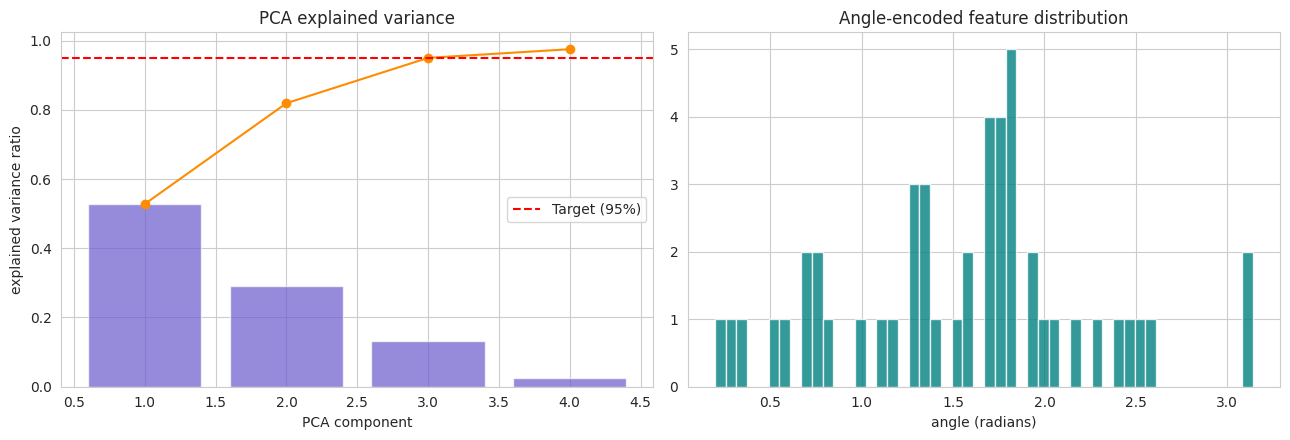

In [ ]:
if USE_PCA:
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
    ax[0].bar(
        range(1, N_QUBITS + 1),
        pca.explained_variance_ratio_,
        color="slateblue",
        alpha=0.7,
    )

    ax[0].plot(
        range(1, N_QUBITS + 1), cum_var[:N_QUBITS], marker="o", color="darkorange"
    )
    if MANUAL_N_QUBITS is None:
        ax[0].axhline(
            TARGET_VARIANCE,
            color="red",
            linestyle="--",
            label=f"Target ({TARGET_VARIANCE * 100:.0f}%)",
        )
        ax[0].legend()
    ax[0].set_xlabel("PCA component")
    ax[0].set_ylabel("explained variance ratio")
    ax[0].set_title("PCA explained variance")
    ax1 = ax[1]
else:
    fig, ax1 = plt.subplots(figsize=(6.5, 4.5))

ax1.hist(A_train.flatten(), bins=50, color="teal", alpha=0.8)
ax1.set_xlabel("angle (radians)")
ax1.set_title("Angle-encoded feature distribution")
plt.tight_layout()
plt.show()

In [ ]:
dev = create_quantum_device(N_QUBITS, backend="default.mixed")
forward_circuit = build_forward_circuit(
    dev, N_QUBITS, N_LAYERS, noise_rate=NOISE_P, reupload=REUPLOAD
)
print(
    f"Quantum device: {dev.name}, wires={N_QUBITS}, layers={N_LAYERS}, reupload={REUPLOAD}, noise_rate={NOISE_P}"
)

Quantum device: default.mixed, wires=4, layers=3, reupload=True, noise_rate=0.01


[grad-variance probe] var=4.787e-08  (BARREN PLATEAU RISK (pre-training probe))
NOTE: this probe uses fresh random inits + a toy purity loss -- it is a pre-training
      heuristic, not a guarantee. Compare against the ACTUAL grad_var logged during
      training below; if training's grad_var is healthy despite a probe warning here,
      report both numbers rather than treating the probe as the final word.


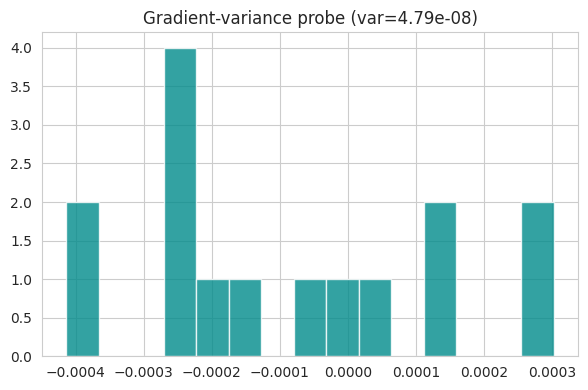

In [ ]:
try:
    grad_var, grad_samples = gradient_variance_probe(
        forward_circuit,
        A_train[:4],
        n_qubits=N_QUBITS,
        n_layers=N_LAYERS,
        n_trials=15,
        device=DEVICE,
    )
    status = (
        "OK"
        if grad_var > BARREN_PLATEAU_VAR_THRESHOLD
        else "BARREN PLATEAU RISK (pre-training probe)"
    )
    print(f"[grad-variance probe] var={grad_var:.3e}  ({status})")
    print(
        "NOTE: this probe uses fresh random inits + a toy purity loss -- it is a pre-training"
    )
    print(
        "      heuristic, not a guarantee. Compare against the ACTUAL grad_var logged during"
    )
    print(
        "      training below; if training's grad_var is healthy despite a probe warning here,"
    )
    print("      report both numbers rather than treating the probe as the final word.")
    plt.figure(figsize=(6, 4))
    plt.hist(grad_samples, bins=15, color="darkcyan", alpha=0.8)
    plt.title(f"Gradient-variance probe (var={grad_var:.2e})")
    plt.tight_layout()
    plt.show()
except RuntimeError as e:
    if is_oom_error(e):
        print("  [OOM] barren-plateau probe skipped (non-critical diagnostic).")
        safe_empty_cache()
    else:
        raise

In [ ]:
LR, EPOCHS = 0.05, 10

theta_final, head_final, prototypes_final, ema_protos_final, history_final = (
    run_batched_safely(
        train_maqt,
        A_train,
        y_train,
        n_classes=N_CLASSES,
        n_qubits=N_QUBITS,
        n_layers=N_LAYERS,
        forward_circuit=forward_circuit,
        device=DEVICE,
        epochs=EPOCHS,
        lr=LR,
        lambda1_max=DEFAULT_LAMBDA1,
        lambda2_max=DEFAULT_LAMBDA2,
        use_weighted_sampler=True,
        log_every=1,
        verbose=True,
        batch_size=TRAIN_BATCH_SIZE,
        min_batch=2,
        label="train_maqt",
        # --- NEW OPTIONAL PARAMETERS ---
        early_stopping=True,  # Enable early stopping
        patience=DEFAULT_PATIENCE,  # Stop after 3 non-improving epochs
        min_delta=0.001,  # Minimum improvement to reset counter
        checkpoint_dir="./checkpoints",  # Directory for crash-safe checkpoints
        checkpoint_every_steps=50,  # Save every 50 batches (not just epoch end)
        log_dir="./logs",  # Directory for JSONL logging
        heartbeat_every_steps=25,  # Print progress every 25 steps
        oom_max_retries=3,  # auto-shrink the batch on CUDA OOM instead of crashing
        notebook_name=NOTEBOOK_NAME,
    )
)
gpu_mem_report("after training")
safe_empty_cache()


print(f"Training completed: {history_final['stop_reason']}")
print(f"Epochs run: {history_final['epochs_ran']}")
print(f"Best epoch: {history_final.get('best_epoch', 'N/A')}")
print(f"Best score: {history_final.get('best_score', 'N/A'):.4f}")
print(f"Stopped early: {history_final.get('stopped_early', False)}")
print(f"Interrupted: {history_final.get('interrupted', False)}")

# If using checkpoints
if history_final.get("interrupted"):
    print(
        "\nTo resume: re-run training cell with resume_from='./checkpoints/maqt-latest.pt'"
    )

epoch  1/10 | loss 1.5523 | L_CE 1.5523 | L_intra 0.0393 | L_inter -0.4083 | grad_var 9.89e-04 | intra_fid 0.961 | inter_TD 0.742 | time 0.7s | peak_mem=21MB | best=1.5523@ep1 | bad=0/3
  saved checkpoint: checkpoints/maqt-epoch001.pt
epoch  2/10 | loss 1.3494 | L_CE 1.4293 | L_intra 0.1253 | L_inter -0.7414 | grad_var 9.37e-04 | intra_fid 0.875 | inter_TD 0.737 | time 0.4s | peak_mem=21MB | best=1.3494@ep2 | bad=0/3
  saved checkpoint: checkpoints/maqt-epoch002.pt
epoch  3/10 | loss 1.1607 | L_CE 1.3280 | L_intra 0.1057 | L_inter -0.7340 | grad_var 4.73e-04 | intra_fid 0.894 | inter_TD 0.731 | time 0.4s | peak_mem=21MB | best=1.1607@ep3 | bad=0/3
  saved checkpoint: checkpoints/maqt-epoch003.pt
epoch  4/10 | loss 1.0493 | L_CE 1.1905 | L_intra 0.1562 | L_inter -0.7309 | grad_var 7.41e-04 | intra_fid 0.844 | inter_TD 0.729 | time 0.4s | peak_mem=21MB | best=1.0493@ep4 | bad=0/3
  saved checkpoint: checkpoints/maqt-epoch004.pt
epoch  5/10 | loss 0.9935 | L_CE 1.1220 | L_intra 0.1789 | L

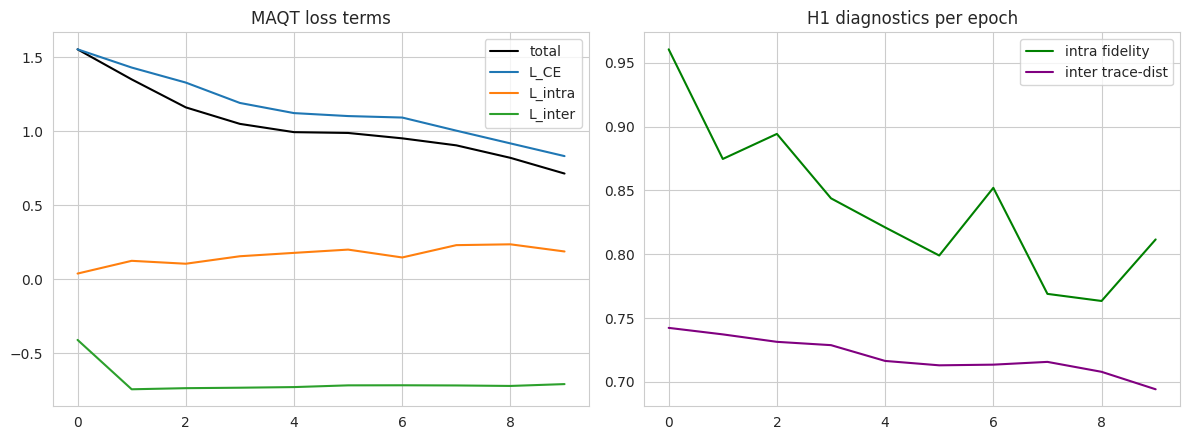

grad_var during training: min=3.80e-04  max=9.89e-04  (compare against the pre-training probe above)


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].plot(history_final["loss"], label="total", color="black")
ax[0].plot(history_final["L_CE"], label="L_CE")
ax[0].plot(history_final["L_intra"], label="L_intra")
ax[0].plot(history_final["L_inter"], label="L_inter")
ax[0].set_title("MAQT loss terms")
ax[0].legend()
ax[1].plot(history_final["intra_fid_gap"], label="intra fidelity", color="green")
ax[1].plot(history_final["inter_trace_dist"], label="inter trace-dist", color="purple")
ax[1].set_title("H1 diagnostics per epoch")
ax[1].legend()
plt.tight_layout()
plt.show()

print(
    f"grad_var during training: min={min(history_final['grad_var']):.2e}  "
    f"max={max(history_final['grad_var']):.2e}  (compare against the pre-training probe above)"
)

In [ ]:
cache = ForwardCache(store_device="cpu")

for key, X_ds in [
    ("train", A_train),
    ("test", A_test),
    ("cal", A_cal),
    ("zeroday", A_zeroday),
]:
    entry = run_batched_safely(
        cache.compute,
        key,
        X_ds,
        theta_final,
        forward_circuit,
        device=DEVICE,
        p=NOISE_P,
        batch_size=QBATCH,
        min_batch=1,
        label=f"cache[{key}]",
    )
    if entry is None:
        print(
            f"  WARNING: could not build cache for '{key}' -- downstream cells using it will be skipped."
        )
    else:
        print(
            f"  cached '{key}': n={entry['n']}, rho shape={tuple(entry['rho'].shape)}"
        )
    safe_empty_cache()

for row in cache.memory_report():
    print(f"  {row['key']:8s}: n={row['n_samples']:5d}  {row['MB']:7.1f} MB (CPU)")

  cached 'train': n=12, rho shape=(12, 16, 16)
  cached 'test': n=5, rho shape=(5, 16, 16)
  cached 'cal': n=5, rho shape=(5, 16, 16)
  cached 'zeroday': n=10, rho shape=(10, 16, 16)
  train   : n=   12      0.0 MB (CPU)
  test    : n=    5      0.0 MB (CPU)
  cal     : n=    5      0.0 MB (CPU)
  zeroday : n=   10      0.0 MB (CPU)


In [ ]:
from pathlib import Path

L_PHI_ANALYTIC = 1.5
ABLATION_SAVE_PATH = "./ablation_artifacts"
Path(ABLATION_SAVE_PATH).mkdir(parents=True, exist_ok=True)

#  Save Configuration
config = {
    "N_QUBITS": N_QUBITS,
    "N_LAYERS": N_LAYERS,
    "N_CLASSES": N_CLASSES,
    "CLASS_NAMES": CLASS_NAMES,
    "NOISE_P": NOISE_P,
    "USE_PCA": USE_PCA,
    "SEED": SEED,
    "PER_CLASS_CAP": PER_CLASS_CAP,
    "DEFAULT_ALPHA": DEFAULT_ALPHA,
}
with open(f"{ABLATION_SAVE_PATH}/config.json", "w") as f:
    json.dump(config, f, indent=2)

#  Save Preprocessors (scaler, pca, label encoder)
with open(f"{ABLATION_SAVE_PATH}/preprocessors.pkl", "wb") as f:
    pickle.dump({"le": le, "scaler": scaler, "pca": pca}, f)

#  Save Labels and Classical Features
for arr, name in [
    (y_train, "y_train"),
    (y_test, "y_test"),
    (y_cal, "y_cal"),
    (X_train_classical, "X_train_classical"),
    (X_test_classical, "X_test_classical"),
    (X_cal_classical, "X_cal_classical"),
    (X_zeroday_classical, "X_zeroday_classical"),
    (A_train, "A_train"),
    (A_test, "A_test"),
    (A_cal, "A_cal"),
    (A_zeroday, "A_zeroday"),
]:
    np.save(f"{ABLATION_SAVE_PATH}/{name}.npy", arr)

#  Save Forward Cache (rho and z matrices)
cache_dict = {}
for key in ["train", "test", "cal", "zeroday"]:
    entry = cache.get(key)
    if entry is not None:
        cache_dict[key] = {
            "rho": entry["rho"].cpu().half(),
            "z": entry["z"].cpu().half() if entry.get("z") is not None else None,
            "n": entry["n"],
        }
torch.save(cache_dict, f"{ABLATION_SAVE_PATH}/forward_cache.pt")

# Save Model Weights and Prototypes
torch.save(
    {
        "theta": theta_final.cpu(),
        "head_state_dict": head_final.state_dict(),
        "prototypes": {k: v.cpu() for k, v in prototypes_final.items()},
        "ema_protos": {k: v.cpu() for k, v in ema_protos_final.protos.items()},
    },
    f"{ABLATION_SAVE_PATH}/model_weights.pt",
)

# Summary
total_size = (
    sum(f.stat().st_size for f in Path(ABLATION_SAVE_PATH).rglob("*") if f.is_file())
    / 1e6
)
print(
    f"Successfully saved ablation artifacts to '{ABLATION_SAVE_PATH}/' ({total_size:.1f} MB)"
)

Successfully saved ablation artifacts to './ablation_artifacts/' (0.1 MB)


                precision    recall  f1-score   support

          DDoS       0.60      1.00      0.75         3
           DoS       0.00      0.00      0.00         2
        Normal       0.00      0.00      0.00         0
Reconnaissance       0.00      0.00      0.00         0

      accuracy                           0.60         5
     macro avg       0.15      0.25      0.19         5
  weighted avg       0.36      0.60      0.45         5



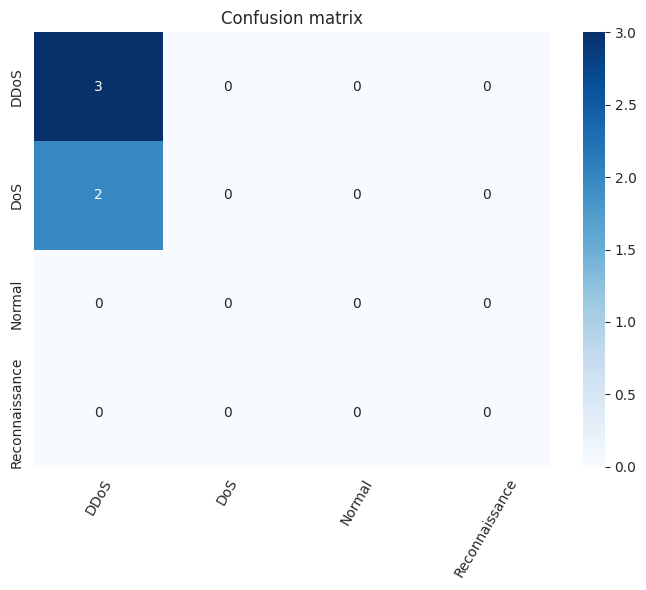


Class pairs with >15% cross-confusion (candidates for feature-engineering review):
  DoS                  -> DDoS                 : 100.0%


In [ ]:
y_true_test, y_pred_test = cached_predict_labels(
    cache.get("test"), y_test, head_final, device=DEVICE, batch_size=CACHE_BATCH
)


print(
    classification_report(
        y_true_test,
        y_pred_test,
        labels=range(N_CLASSES),
        target_names=CLASS_NAMES,
        zero_division=0,
    )
)

cm = confusion_matrix(y_true_test, y_pred_test, labels=range(N_CLASSES))
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
)
plt.title("Confusion matrix")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
worst_pairs = []
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        if i != j and cm_norm[i, j] > 0.15:
            worst_pairs.append((CLASS_NAMES[i], CLASS_NAMES[j], cm_norm[i, j]))
if worst_pairs:
    print(
        "\nClass pairs with >15% cross-confusion (candidates for feature-engineering review):"
    )
    for a, b, r in sorted(worst_pairs, key=lambda t: -t[2]):
        print(f"  {a:20s} -> {b:20s} : {r:.1%}")